<a href="{{ colab_base_laboratorios }}/Laboratorio_02_pandas_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Lab 2: Estadística Descriptiva Básica 2

## Series de tiempo

El siguiente [dataset](https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv) contiene información del precio del eur/usd  desde el 05/07/2022/ hasta el 12/05/2023 con periodicidad de una hora. El data frame contiene el precio de apertura, cierrre, valor más bajo cotizado, valor más alto cotizado, volumen, spread etc. Para este dataset, realizar lo siguiente:


1. Leer el dataset desde el github.
2. Definir como indice la columna time.
3. Obtenga información del data frame.

4. Determine si hay null, nan en el data frame.

5. Emplea la notacion Pascal Case y trabaja solo con la columa del precio de cierre del eur/usd.  

6. Ahora vamos a determinar cual es la mejor distribución estadística que se ajusta a la diferencia del precio de cierre cada hora, para ello realizamos lo siguiente:
- Determine la diferencia de precio entre horas, agregue una nueva columna llamada DiffPrice, en este punto tu dataframe debe tener solo dos columnas Close, DiffPrice y el indice debe ser el tiempo.
- Para la nueva columna construya un histograma de los datos.
- Determine la mejor distribucion estadística que se ajusta al histograma anterior, para ello puede emplear lo siguente:


https://pypi.org/project/fitter/

```python


from fitter import Fitter, get_common_distributions, get_distributions

f = Fitter(data,
           distributions=['gamma',
                          'lognorm',
                          "beta",
                          "burr",
                          "norm"])
f.fit()
f.summary()
#Indentificamos la mejor distribucion con el error cuadratico medio
f.get_best(method = 'sumsquare_error')
#Indentificamos parametros de la distrubicion beta
f.fitted_param["beta"]

```

Con el metodo get_distributions(), podemos ver todas las distribuciones estadisticas de la libreria. Ajusta a la mejor.  Puede consultar [esta](https://medium.com/the-researchers-guide/finding-the-best-distribution-that-fits-your-data-using-pythons-fitter-library-319a5a0972e9)  página si desea ver un ejemplo.


7. Para el data frame, seleccionemos solo los datos del 2023.

8. El comando groupby permite agrupar los datos con la periodicidad deseada: 1 dias, 2 dias, 1 mes etc. Determina el promedio con una periodicidad de 15 dias, con periodidicidad de 1 semana, y una periodicidad de 1 mes

```python
  df.groupby(pd.Grouper(key='time', freq='15D')).mean()
```

9. Para los datos asociados a los meses de 2023, construya un histograma para cada mes.  Para ello puedo emplear el metodo groupby. Notetese que si no  realiza una operación después de aplicar el metodo grouby, podrias iterar sobre dicho objeto, por ejemplo:

```python
q=df.groupby(pd.Grouper(key='time', freq='15D'))

for name, group in q:
  print(name, group)
```


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fitter import Fitter
from scipy import stats
import numpy as np

# 1. Leer el dataset desde GitHub
url_eurusd = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv"
df_eurusd = pd.read_csv(url_eurusd)

df_eurusd.head()

,Unnamed: 0,time,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
0,0,2022-07-25 13:00:00,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
1,1,2022-07-25 14:00:00,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2,2,2022-07-25 15:00:00,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
3,3,2022-07-25 16:00:00,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
4,4,2022-07-25 17:00:00,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [26]:
# 2. Definir la columna 'time' como índice
df_eurusd['time'] = pd.to_datetime(df_eurusd['time'])
df_eurusd = df_eurusd.set_index('time')

df_eurusd.head()

,Unnamed: 0,open,high,low,close,tick_volume,spread,real_volume,MeanCloseOpen,Diff_Close,Diff_Open,Diff_MeanCloseOpen
time,,,,,,,,,,,,
2022-07-25 13:00:00,0,1.02427,1.02430,1.02145,1.02345,3927,8,0,1.023860,-0.00046,-0.00082,-0.000640
2022-07-25 14:00:00,1,1.02345,1.02578,1.02288,1.02299,5344,8,0,1.023220,-0.00046,-0.00082,-0.000640
2022-07-25 15:00:00,2,1.02303,1.02476,1.02230,1.02457,5524,8,0,1.023800,0.00158,-0.00042,0.000580
2022-07-25 16:00:00,3,1.02454,1.02548,1.02355,1.02485,5234,8,0,1.024695,0.00028,0.00151,0.000895
2022-07-25 17:00:00,4,1.02485,1.02514,1.02030,1.02181,9031,7,0,1.023330,-0.00304,0.00031,-0.001365


In [27]:
# 3. Información general
df_eurusd.info()

# 4. Determinar si hay nulos
print("\nValores nulos en el dataset EUR/USD:")
print(df_eurusd.isnull().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB

Valores nulos en el dataset EUR/USD:
Unnamed: 0            0
open                  0
high                  0
low                 

In [28]:
# 5. Notación PascalCase para el precio de cierre y seleccionar solo esa columna
df_eurusd = df_eurusd.rename(columns={'close': 'ClosePrice'})
df_close = df_eurusd[['ClosePrice']].copy()

df_close.head()

,ClosePrice
time,
2022-07-25 13:00:00,1.02345
2022-07-25 14:00:00,1.02299
2022-07-25 15:00:00,1.02457
2022-07-25 16:00:00,1.02485
2022-07-25 17:00:00,1.02181


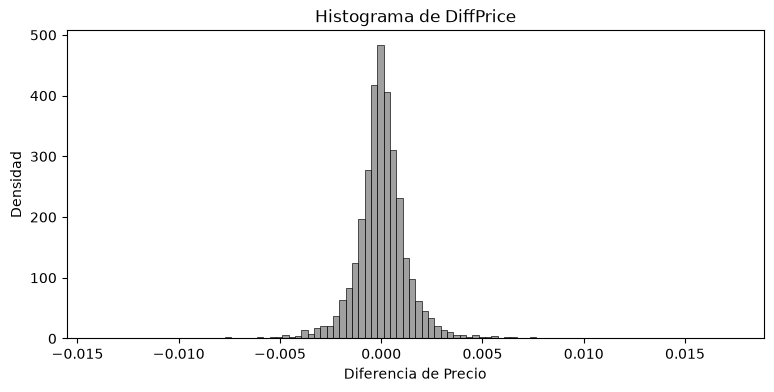

Ronda 1: ajustando con fitter...


2026-09-03 19:58:04.835 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted laplace: error=6322.455645, AIC=-53025.02, KS=0.0174
2026-09-03 19:58:04.837 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=106805.745273, AIC=-51484.48, KS=0.0905
2026-09-03 19:58:04.847 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted logistic: error=27640.841017, AIC=-52679.43, KS=0.0441
2026-09-03 19:58:04.896 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted cauchy: error=23100.468611, AIC=-52472.71, KS=0.0424
2026-09-03 19:58:05.042 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted t: error=2626.582638, AIC=-53088.24, KS=0.0125


Ronda 1 mejor: t | KS_D=0.0125 | KS_p=0.4156 | BIC=-53068.69

=== RESULTADO FINAL ===
Motor: fitter
Distribución: t
hist_MSE: 1.737668e+01
KS D: 0.012468
KS p-value: 0.415608
AIC: -53088.24
BIC: -53068.69
Pasa criterio: True
Parámetros: (np.float64(1.9892593652664312), np.float64(-3.535701331424864e-06), np.float64(0.0007266878617516969))

Top 5 candidatos:
engine dist  pass     ks_D  ks_pvalue           bic  hist_mse
fitter    t  True 0.012468   0.415608 -53068.688702 17.376678


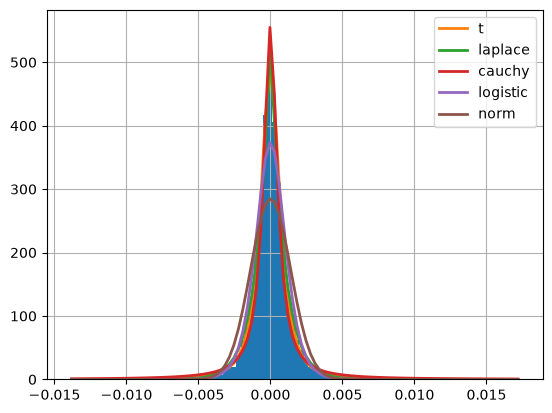

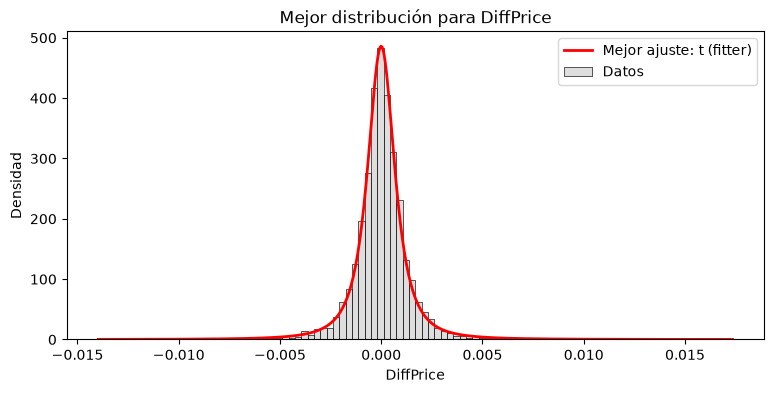

In [34]:
import warnings
warnings.filterwarnings("ignore")

# =========================
# 1) Preparar datos
# =========================
# Si ya trabajas con df_close, usa este bloque:
if "df_close" in globals():
    df_work = df_close.copy()
elif "df" in globals():
    df_work = df.copy()
else:
    raise NameError("No existe ni 'df_close' ni 'df'. Carga tus datos primero.")

if "ClosePrice" not in df_work.columns:
    raise ValueError(f"No existe 'ClosePrice'. Columnas disponibles: {list(df_work.columns)}")

df_work["DiffPrice"] = df_work["ClosePrice"].diff()
data = df_work["DiffPrice"].dropna().values

if len(data) < 30:
    raise ValueError("Muy pocos datos para ajustar distribuciones de forma confiable (n < 30).")

plt.figure(figsize=(9, 4))
sns.histplot(data, bins=100, kde=False, color="gray", stat="density")
plt.title("Histograma de DiffPrice")
plt.xlabel("Diferencia de Precio")
plt.ylabel("Densidad")
plt.show()


# =========================
# 2) Utilidades de evaluación
# =========================
def histogram_mse(x, dist_obj, params, bins=80):
    """
    MSE entre densidad del histograma y PDF teórica en centros de bins.
    Más estable que SSE/var(data).
    """
    hist, edges = np.histogram(x, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    pdf = dist_obj.pdf(centers, *params)
    pdf = np.nan_to_num(pdf, nan=0.0, posinf=0.0, neginf=0.0)
    mse = np.mean((hist - pdf) ** 2)
    return float(mse)

def ks_test(x, dist_obj, params):
    D, pvalue = stats.kstest(x, dist_obj.cdf, args=params)
    return float(D), float(pvalue)

def aic_bic(x, dist_obj, params):
    logpdf = dist_obj.logpdf(x, *params)
    logpdf = np.nan_to_num(logpdf, nan=-1e10, neginf=-1e10, posinf=-1e10)
    ll = np.sum(logpdf)
    k = len(params)
    n = len(x)
    aic = 2 * k - 2 * ll
    bic = k * np.log(n) - 2 * ll
    return float(aic), float(bic)

def quality_pass(result, min_ks_pvalue=0.05, max_ks_D=0.03):
    """
    Gate principal con KS (más robusto que SSE normalizado por var).
    """
    return (result["ks_pvalue"] >= min_ks_pvalue) and (result["ks_D"] <= max_ks_D)


# =========================
# 3) Evaluador de distribuciones
# =========================
def evaluate_distribution(x, dname, engine):
    dist = getattr(stats, dname)
    params = dist.fit(x)

    mse = histogram_mse(x, dist, params, bins=80)
    ks_D, ks_p = ks_test(x, dist, params)
    aic, bic = aic_bic(x, dist, params)

    result = {
        "engine": engine,
        "dist": dname,
        "params": params,
        "hist_mse": mse,
        "ks_D": ks_D,
        "ks_pvalue": ks_p,
        "aic": aic,
        "bic": bic,
    }
    result["pass"] = quality_pass(result)
    return result


# =========================
# 4) Ronda 1 con fitter (lista corta)
# =========================
round1_dists = ["norm", "t", "laplace", "logistic", "cauchy"]

print("Ronda 1: ajustando con fitter...")
f = Fitter(data, distributions=round1_dists, timeout=30)
f.fit()

summary_df = f.summary()
best_r1_name = summary_df.index[0]

# Re-evaluación homogénea con scipy + nuestras métricas
result_r1 = evaluate_distribution(data, best_r1_name, engine="fitter")
results = [result_r1]

print(
    f"Ronda 1 mejor: {result_r1['dist']} | "
    f"KS_D={result_r1['ks_D']:.4f} | KS_p={result_r1['ks_pvalue']:.4g} | "
    f"BIC={result_r1['bic']:.2f}"
)


# =========================
# 5) Fallback con scipy (solo si falla)
# =========================
if not result_r1["pass"]:
    print("Ronda 1 no cumple criterio. Ejecutando fallback con scipy.stats...")

    round2_dists = ["t", "laplace", "logistic", "norm", "cauchy", "gennorm", "johnsonsu"]
    for dname in round2_dists:
        try:
            r = evaluate_distribution(data, dname, engine="scipy")
            results.append(r)
        except Exception:
            continue


# =========================
# 6) Selección final
# =========================
results_df = pd.DataFrame(results)

# Prioridad:
# 1) que pase el gate KS
# 2) menor BIC
# 3) menor KS_D
# 4) menor hist_mse
results_df["pass_rank"] = results_df["pass"].astype(int)
results_df = results_df.sort_values(
    by=["pass_rank", "bic", "ks_D", "hist_mse"],
    ascending=[False, True, True, True]
).reset_index(drop=True)

best = results_df.iloc[0].to_dict()

print("\n=== RESULTADO FINAL ===")
print(f"Motor: {best['engine']}")
print(f"Distribución: {best['dist']}")
print(f"hist_MSE: {best['hist_mse']:.6e}")
print(f"KS D: {best['ks_D']:.6f}")
print(f"KS p-value: {best['ks_pvalue']:.6g}")
print(f"AIC: {best['aic']:.2f}")
print(f"BIC: {best['bic']:.2f}")
print(f"Pasa criterio: {bool(best['pass'])}")
print(f"Parámetros: {best['params']}")

display_cols = ["engine", "dist", "pass", "ks_D", "ks_pvalue", "bic", "hist_mse"]
print("\nTop 5 candidatos:")
print(results_df[display_cols].head(5).to_string(index=False))


# =========================
# 7) Visual final
# =========================
best_dist = getattr(stats, best["dist"])
best_params = best["params"]

x_plot = np.linspace(np.min(data), np.max(data), 600)
pdf_best = best_dist.pdf(x_plot, *best_params)
pdf_best = np.nan_to_num(pdf_best, nan=0.0, posinf=0.0, neginf=0.0)

plt.figure(figsize=(9, 4))
sns.histplot(data, bins=100, stat="density", color="lightgray", label="Datos")
plt.plot(x_plot, pdf_best, "r-", lw=2, label=f"Mejor ajuste: {best['dist']} ({best['engine']})")
plt.title("Mejor distribución para DiffPrice")
plt.xlabel("DiffPrice")
plt.ylabel("Densidad")
plt.legend()
plt.show()

# Explicación del código de ajuste de distribuciones (con fallback)

## ¿Qué hace este flujo en general?
Este script toma la serie de cambios de precio (`DiffPrice`), prueba distribuciones estadísticas y selecciona la mejor usando criterios cuantitativos.  
Si la primera ronda no cumple calidad mínima, activa una segunda ronda automática con más distribuciones.

---

## Importaciones: ¿para qué sirve cada una?

### `import warnings`
Se usa para controlar mensajes de advertencia (warnings) durante el ajuste.

### `import numpy as np`
Librería numérica base. Aquí se usa para:
- arreglos (`values`)
- histograma (`np.histogram`)
- manejo de `NaN` e infinitos (`np.nan_to_num`)
- varianza (`np.var`)
- suma (`np.sum`)
- malla de graficación (`np.linspace`)

### `from fitter import Fitter`
Motor de ajuste automático de distribuciones en la primera ronda (`round1`).

### `from scipy import stats`
Catálogo de distribuciones y pruebas estadísticas:
- `stats.kstest` para prueba KS
- distribuciones (`norm`, `t`, `laplace`, etc.)
- `fit`, `pdf`, `cdf`, `logpdf` de cada distribución

---

## ¿Por qué importaste `warnings` y usaste `warnings.filterwarnings("ignore")`?
Durante ajustes de distribuciones, especialmente con colas pesadas o parámetros complejos, SciPy/Fitter puede emitir advertencias numéricas (overflow, convergencia, invalid value, etc.).  
`warnings.filterwarnings("ignore")` oculta esos mensajes para que la salida sea más limpia.

**Importante:** no corrige errores, solo silencia advertencias.  
Para depuración o entrega formal, conviene quitarlo o cambiarlo por filtros más específicos.

---

## Sección 1: Preparar datos
1. Copia del DataFrame (`df.copy()`).
2. Cálculo de `DiffPrice = ClosePrice.diff()`.
3. Elimina `NaN` inicial.
4. Valida tamaño mínimo (`n >= 30`).
5. Grafica histograma inicial para inspección visual.

---

## Sección 2: Funciones auxiliares

### `sse_vs_histogram(x, dist_obj, params, bins=80)`
Calcula el **SSE** (suma de errores cuadrados) entre:
- densidad empírica (histograma)
- densidad teórica (`pdf`) de una distribución ajustada

Menor SSE ⇒ mejor ajuste visual/densidad.

### `ks_test(x, dist_obj, params)`
Aplica prueba **Kolmogorov-Smirnov** comparando muestra vs CDF teórica.  
Devuelve:
- `D` (distancia máxima)
- `pvalue` (evidencia contra buen ajuste)

### `aic_bic(x, dist_obj, params)`
Calcula criterios de información:
- **AIC**
- **BIC**

Ambos penalizan complejidad (más parámetros).  
Menor valor ⇒ mejor balance ajuste-complejidad.

### `quality_pass(result, max_sse=0.12, min_ks_pvalue=0.01)`
Regla booleana de aceptación:
- `sse_norm <= max_sse`
- `ks_pvalue >= min_ks_pvalue`

Convierte “se ve bien/mal” en criterio automático.

---

## Sección 3: Ronda 1 con `Fitter`
1. Prueba lista inicial de distribuciones.
2. Toma la mejor por `f.summary()`.
3. Recalcula métricas comparables (`SSE`, `SSE_norm`, `KS`, `AIC`, `BIC`).
4. Marca si pasa criterio (`pass`).

---

## Sección 4: Fallback automático (Ronda 2 con SciPy)
Solo se ejecuta si ronda 1 falla.  
Para cada distribución candidata:
1. Ajusta parámetros con `dist.fit(data)`.
2. Calcula métricas.
3. Guarda resultado.
4. Si alguna distribución falla numéricamente, se omite y continúa.

---

## Sección 5: Selección final
Construye `results_df` y ordena por prioridad:
1. `pass` (primero las que pasan)
2. menor `BIC`
3. menor `SSE_norm`

Luego imprime ganador final y top 5 candidatos.

---

## Sección 6: Visualización final
Grafica histograma de datos + PDF de la distribución ganadora para interpretación final.

---

## Idea clave del diseño
No depende de una sola librería ni solo de inspección visual:
- Primera ronda rápida con `fitter`
- Fallback automático con `scipy.stats`
- Selección objetiva por métricas

In [42]:
# 7. Seleccionar datos del año 2023
df_2023 = df_close.loc[df_close.index.year == 2023, ['ClosePrice']].copy()
df_2023.head()


,ClosePrice
time,
2023-01-02 00:00:00,1.06796
2023-01-02 01:00:00,1.06965
2023-01-02 02:00:00,1.07058
2023-01-02 03:00:00,1.06896
2023-01-02 04:00:00,1.06880


In [37]:
# 8. Promedios cada 15 días, 1 semana y 1 mes[cite: 1]
promedio_15d = df_2023.groupby(pd.Grouper(freq='15D'))['ClosePrice'].mean()
promedio_1w = df_2023.groupby(pd.Grouper(freq='1W'))['ClosePrice'].mean()
promedio_1m = df_2023.groupby(pd.Grouper(freq='1ME'))['ClosePrice'].mean()

print("--- Promedio Mensual 2023 ---")
print(promedio_1m)

--- Promedio Mensual 2023 ---
time
2023-01-31    1.077463
2023-02-28    1.071167
2023-03-31    1.070874
2023-04-30    1.096051
2023-05-31    1.098980
Freq: ME, Name: ClosePrice, dtype: float64


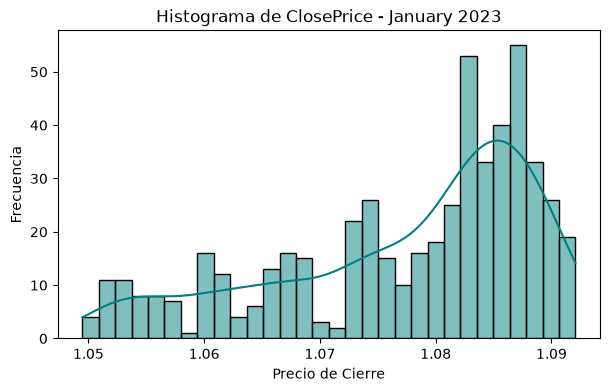

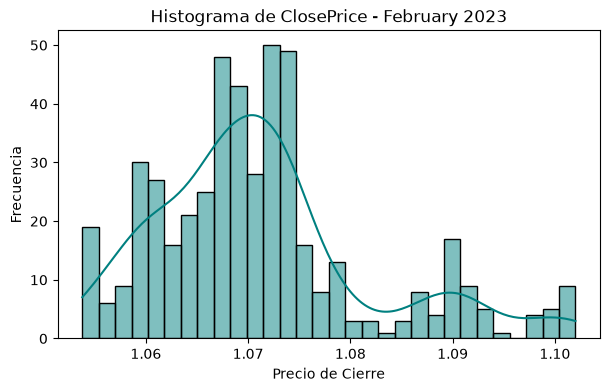

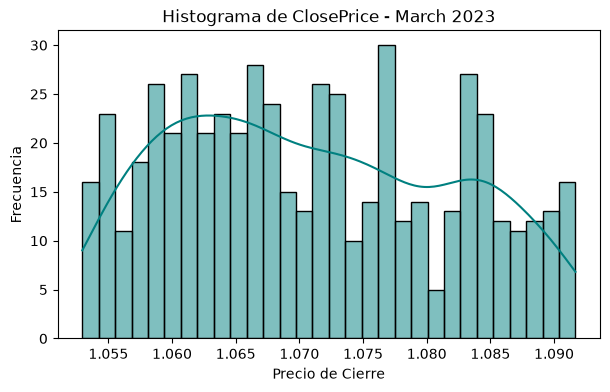

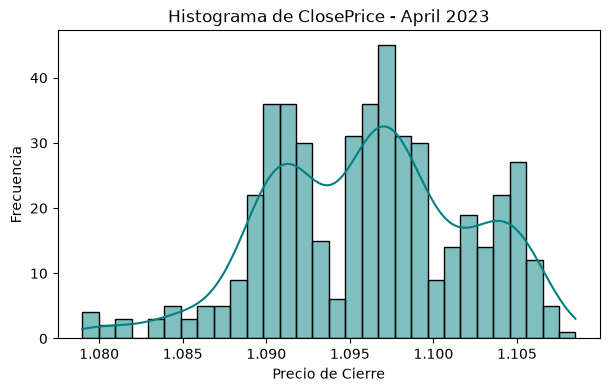

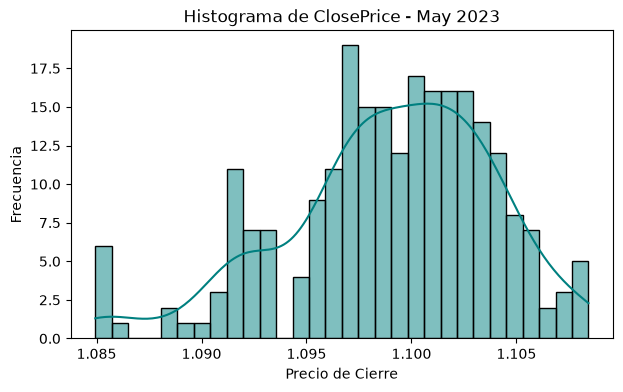

In [38]:
# 9. Histogramas para cada mes del 2023 usando el ciclo for con name y group[cite: 1]
monthly_groups = df_2023.groupby(pd.Grouper(freq='1ME'))

for name, group in monthly_groups:
    if not group.empty:
        month_name = name.strftime('%B %Y')
        plt.figure(figsize=(7, 4))
        sns.histplot(group['ClosePrice'], bins=30, kde=True, color='teal')
        plt.title(f'Histograma de ClosePrice - {month_name}')
        plt.xlabel('Precio de Cierre')
        plt.ylabel('Frecuencia')
        plt.show()

## Análisis de datos con pandas.

Para el siguiente [dataset](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29) realizar lo siguiente:


1. Leer los datos desde una página web.

2. Renombrar las columnas en formato PascalCase.

3. Utilizar los métodos `head()`, `tail()`, `describe()` e `info()` para obtener información sobre el `DataFrame`.

4. Contabilizar la cantidad de valores nulos (`null` o `NaN`) en el `DataFrame`.
   Si se encuentran valores nulos, ¿qué estrategia propondrías para reemplazarlos?

5. Identificar los valores únicos en la columna `target` que representan las etiquetas B y M (Benigno y Maligno, respectivamente).
   Utiliza el método `unique()` para mostrar estos valores.

6. Realizar un conteo de los casos etiquetados como B y M utilizando la librería `seaborn` y el método `countplot()`:

```python
import seaborn as sns
sns.countplot?
```

7. Agregar una nueva columna llamada `DiagnosisNumeric` donde se asigna el valor 0 a la etiqueta B (Benigno) y el valor 1 a la etiqueta M (Maligno).


8. Normalizar cada columna respecto a su media y desviación estándar utilizando la fórmula:  
   `(x - mean(x)) / std(x)`

9. Agrupar características similares y calcular su promedio.
   Para las siguientes características:

```python
['RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"]
```

Usa expresiones regulares para identificar patrones comunes, como `radius1`, `radius2`,`radius3`, etc., y calcular los promedios. Por ejemplo:

```python
re.match(r'^[a-zA-Z_]+', "holamundo12341").group(0)
```

También puedes utilizar el método `startswith()` para buscar estos patrones en los nombres de las columnas.


10. Crear un gráfico donde se muestre el histograma de la columna `RadiusMean` separado por las etiquetas B y M, utilizando colores diferentes (naranja y azul, respectivamente) para cada diagnóstico.

11. Generar gráficos de violín para múltiples características.
   Para las columnas:

   - `RadiusMean`
   - `TextureMean`
   - `PerimeterMean`
   - `AreaMean`
   - `SmoothnessMean`
   - `CompactnessMean`
   - `ConcavityMean`
   - `ConcavePointsMean`
   - `Symmetry3`
   - `FractalDimension3`

   Realiza un gráfico múltiple tipo violín, como en el siguiente ejemplo:

```python
data = pd.melt(df.iloc[:, 0:10], id_vars="Diagnosis", var_name="features", value_name="value")
sns.violinplot(x="features", y="value", hue="Diagnosis", data=data, split=True, inner="quart")
plt.xticks(rotation=45)
```


12.  Determinar y eliminar los valores atípicos (`outliers`) en la columna `RadiusMean`.

Para identificarlos, construye un gráfico tipo `boxplot`:

```python
df.boxplot(column="RadiusMean", by='Diagnosis', sym='k.', figsize=(18,6))
```

Usa el rango intercuartílico (IQR) para definir los outliers. Los valores fuera del rango [Q1 - 1.5 * IQR, Q3 + 1.5 * IQR] se consideran outliers. Ejemplo de cómo eliminar estos valores:

```python
Q1 = df['edad'].quantile(0.25)
Q3 = df['edad'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['edad'] < (Q1 - 1.5 * IQR)) | (df['edad'] > (Q3 + 1.5 * IQR)))]
```

Otra alternativa es utilizar el puntaje Z para detectar `outliers`:

```python
df = df[(np.abs(stats.zscore(df['edad'])) < 3)]
```



13. Encontrar la matrix de correlación, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

14. ¿Que otro tipo de gráficos pueden ser realizados para entender mejor los datos?



In [47]:
import re

# 1. Leer los datos desde la página web
url_cancer = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

column_names = [
    'id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean',
    'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se',
    'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se',
    'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst',
    'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df_cancer = pd.read_csv(url_cancer, header=None, names=column_names)

# 2. Renombrar las columnas en formato PascalCase
def to_pascal_case(text):
    return ''.join(word.capitalize() for word in text.split('_'))

df_cancer.columns = [to_pascal_case(col) for col in df_cancer.columns]
df_cancer.head()

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [48]:
# 3. Utilizar los métodos head(), tail(), describe() e info()
print("--- INFO ---")
df_cancer.info()

print("\n--- HEAD ---")
display(df_cancer.head())

print("\n--- TAIL ---")
display(df_cancer.tail())

print("\n--- DESCRIBE ---")
display(df_cancer.describe())

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Id                     569 non-null    int64  
 1   Diagnosis              569 non-null    str    
 2   RadiusMean             569 non-null    float64
 3   TextureMean            569 non-null    float64
 4   PerimeterMean          569 non-null    float64
 5   AreaMean               569 non-null    float64
 6   SmoothnessMean         569 non-null    float64
 7   CompactnessMean        569 non-null    float64
 8   ConcavityMean          569 non-null    float64
 9   ConcavePointsMean      569 non-null    float64
 10  SymmetryMean           569 non-null    float64
 11  FractalDimensionMean   569 non-null    float64
 12  RadiusSe               569 non-null    float64
 13  TextureSe              569 non-null    float64
 14  PerimeterSe            569 non-null    float64
 15  Area

,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- TAIL ---


,Id,Diagnosis,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039



--- DESCRIBE ---


,Id,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Cantidad total de valores nulos: 0

Valores únicos en Diagnosis: <StringArray>
['M', 'B']
Length: 2, dtype: str


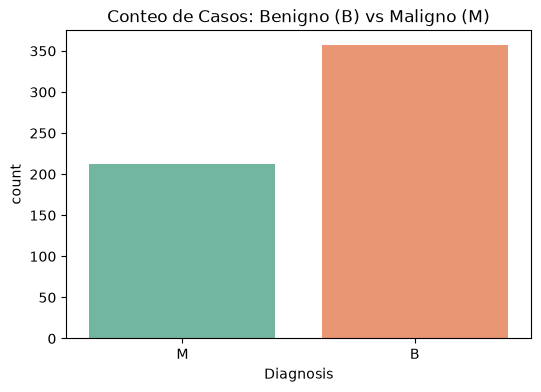

In [50]:
# 4. Contabilizar la cantidad de valores nulos
nulos_totales = df_cancer.isnull().sum().sum()
print(f"Cantidad total de valores nulos: {nulos_totales}")
# Estrategia propuesta en caso de nulos: Imputar valores usando la mediana para variables continuas.

# 5. Identificar valores únicos en la columna de diagnóstico (B y M)
valores_unicos = df_cancer['Diagnosis'].unique()
print(f"\nValores únicos en Diagnosis: {valores_unicos}")

# 6. Conteo de los casos etiquetados utilizando seaborn countplot
plt.figure(figsize=(6, 4))
sns.countplot(data=df_cancer, x='Diagnosis', palette='Set2')
plt.title('Conteo de Casos: Benigno (B) vs Maligno (M)')
plt.show()

# 7. Agregar nueva columna DiagnosisNumeric (B=0, M=1)
df_cancer['DiagnosisNumeric'] = df_cancer['Diagnosis'].map({'B': 0, 'M': 1})

In [ ]:
# 8. Normalizar cada columna respecto a su media y desviación estándar: (x - mean(x)) / std(x)
numeric_cols = df_cancer.select_dtypes(include=[np.number]).columns.drop(['Id', 'DiagnosisNumeric'])
df_norm = df_cancer.copy()
df_norm[numeric_cols] = (df_cancer[numeric_cols] - df_cancer[numeric_cols].mean()) / df_cancer[numeric_cols].std()

#9.

# 1. Definir la lista de las 10 características base de la media (o filtrar las columnas que terminan en 'Mean')
features_mean = [
    'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean',
    'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean'
]

# 2. Ejemplo usando expresiones regulares para extraer la raíz base (ejemplo: 'RadiusMean' -> 'Radius')
base_patterns = [re.match(r'^[a-zA-Z]+(?=Mean)', col).group(0) for col in features_mean]

# 3. Calcular el promedio de cada característica específica solicitada
promedios_individuales = df_cancer[features_mean].mean()

print("--- PROMEDIOS POR CARACTERÍSTICA ('Mean') ---")
display(promedios_individuales)

# 4. Agrupar TODAS las columnas del dataset por su raíz común (usando startswith) y calcular el promedio del grupo
# Esto agrupa por ejemplo: RadiusMean, RadiusSe, RadiusWorst bajo la familia 'Radius'
promedios_por_grupo = {}

for prefix in base_patterns:
    # Buscar todas las columnas que comiencen con el patrón (ej. 'Radius')
    cols_grupo = [col for col in df_cancer.columns if col.startswith(prefix)]
    
    # Calcular el promedio general de todas las mediciones de esa familia
    promedios_por_grupo[prefix] = df_cancer[cols_grupo].mean().mean()

df_promedios_grupos = pd.DataFrame.from_dict(promedios_por_grupo, orient='index', columns=['PromedioGeneralGrupo'])

print("\n--- PROMEDIO AGRUPADO POR FAMILIA DE CARACTERÍSTICAS ---")
display(df_promedios_grupos)

--- PROMEDIOS POR CARACTERÍSTICA ('Mean') ---


RadiusMean               14.127292
TextureMean              19.289649
PerimeterMean            91.969033
AreaMean                654.889104
SmoothnessMean            0.096360
CompactnessMean           0.104341
ConcavityMean             0.088799
ConcavePointsMean         0.048919
SymmetryMean              0.181162
FractalDimensionMean      0.062798
dtype: float64


--- PROMEDIO AGRUPADO POR FAMILIA DE CARACTERÍSTICAS ---


,PromedioGeneralGrupo
Radius,10.267218
Texture,15.394575
Perimeter,67.365435
Area,525.269770
Smoothness,0.078590
Compactness,0.128028
Concavity,0.130961
ConcavePoints,0.058441
Symmetry,0.163927
FractalDimension,0.050179


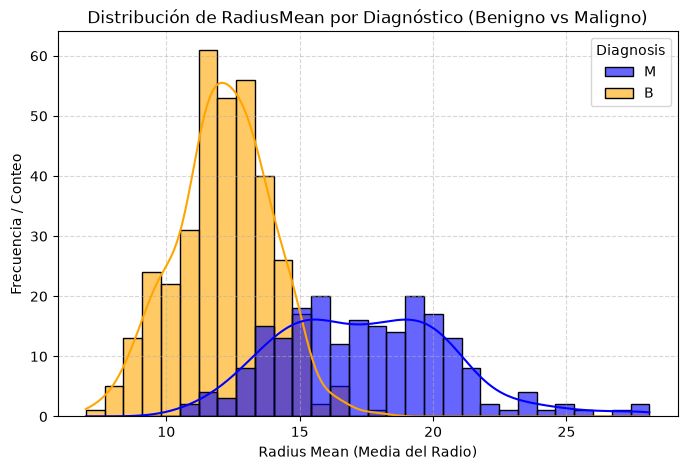

In [53]:
#10
# Configurar el tamaño de la figura
plt.figure(figsize=(8, 5))

# Crear el histograma con seaborn especificando la paleta personalizada
sns.histplot(
    data=df_cancer,
    x='RadiusMean',
    hue='Diagnosis',
    palette={'B': 'orange', 'M': 'blue'},
    bins=30,
    kde=True,
    alpha=0.6,
)

# Títulos y etiquetas del gráfico
plt.title(
    'Distribución de RadiusMean por Diagnóstico (Benigno vs Maligno)',
    fontsize=12,
)
plt.xlabel('Radius Mean (Media del Radio)', fontsize=10)
plt.ylabel('Frecuencia / Conteo', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar el gráfico
plt.show()

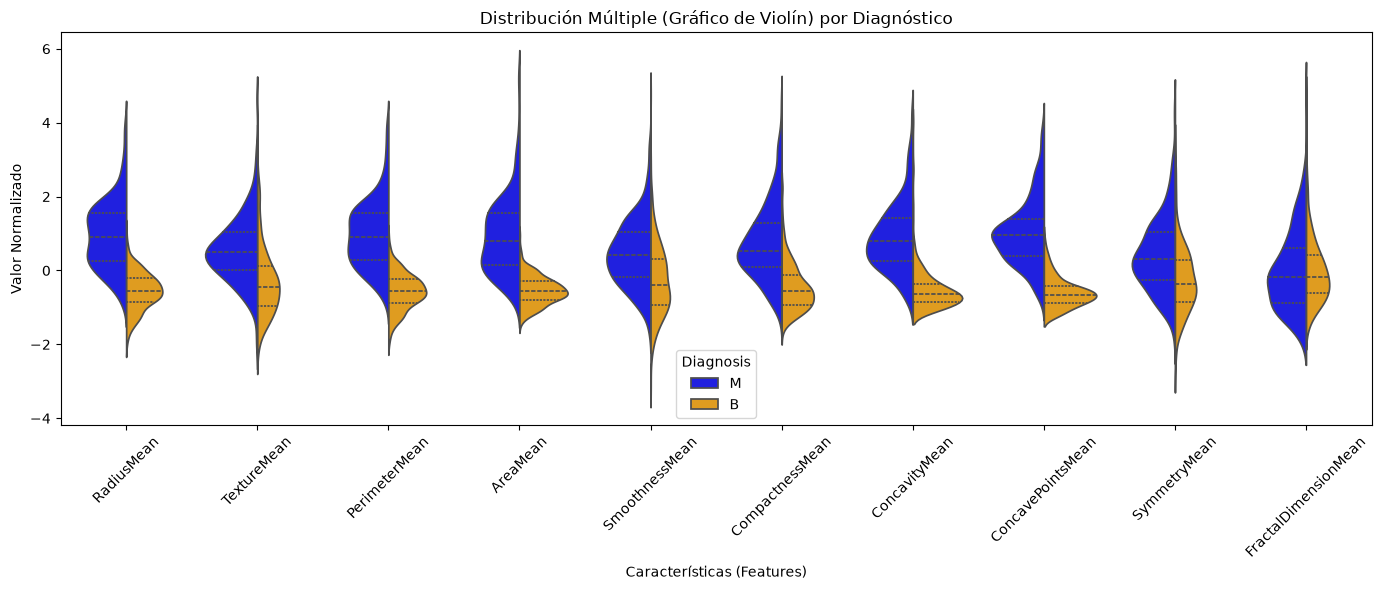

In [58]:

# 1. Lista exacta de características solicitadas en el numeral 11
violin_features = [
    'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 
    'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 
    'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean'
]

# 2. Transformar el DataFrame a formato largo (melt)
# Es crucial usar df_norm (los datos normalizados del punto 8) porque estas variables 
# tienen escalas muy diferentes (ej. Area es enorme comparado con Smoothness).
data_melted = pd.melt(
    df_norm, 
    id_vars=["Diagnosis"], 
    value_vars=violin_features, 
    var_name="features", 
    value_name="value"
)

# 3. Crear el gráfico de violín
plt.figure(figsize=(14, 6))
sns.violinplot(
    x="features", 
    y="value", 
    hue="Diagnosis", 
    data=data_melted, 
    split=True, 
    inner="quart",
    palette={'B': 'orange', 'M': 'blue'}
)

# 4. Ajustes estéticos
plt.xticks(rotation=45)
plt.title('Distribución Múltiple (Gráfico de Violín) por Diagnóstico')
plt.xlabel('Características (Features)')
plt.ylabel('Valor Normalizado')
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

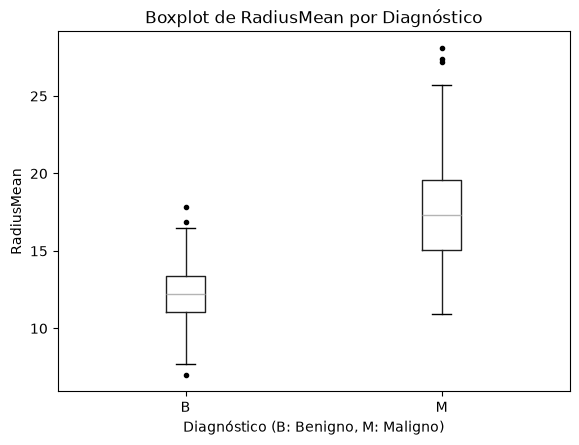

Tamaño original del dataset: 569 filas
Tamaño del dataset tras eliminar outliers en RadiusMean: 555 filas


In [65]:

# 1. Construir el gráfico de caja (boxplot) para RadiusMean separado por diagnóstico
plt.figure(figsize=(10, 5))
df_cancer.boxplot(column="RadiusMean", by='Diagnosis', grid=False, sym='k.')
plt.title('Boxplot de RadiusMean por Diagnóstico')
plt.suptitle('')  # Limpiar el subtítulo automático de pandas
plt.xlabel('Diagnóstico (B: Benigno, M: Maligno)')
plt.ylabel('RadiusMean')
plt.show()

# 2. Calcular los cuartiles y el Rango Intercuartílico (IQR) para RadiusMean
Q1 = df_cancer['RadiusMean'].quantile(0.25)
Q3 = df_cancer['RadiusMean'].quantile(0.75)
IQR = Q3 - Q1

# 3. Definir los límites inferior y superior para el filtrado
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filtrar y eliminar los valores atípicos (outliers) del DataFrame
df_clean_cancer = df_cancer[~((df_cancer['RadiusMean'] < lower_bound) | (df_cancer['RadiusMean'] > upper_bound))]

print(f"Tamaño original del dataset: {len(df_cancer)} filas")
print(f"Tamaño del dataset tras eliminar outliers en RadiusMean: {len(df_clean_cancer)} filas")

In [68]:
# 13. Matriz de correlación

# Seleccionar únicamente las columnas numéricas
df_numerico = df_clean_cancer.select_dtypes(include="number")

# Excluir la variable de diagnóstico numérica si existe
df_numerico = df_numerico.drop(
    columns=["DiagnosisNumeric"],
    errors="ignore"
)

# Calcular la matriz de correlación
matriz_correlacion = df_numerico.corr()

# Mostrar la matriz
display(matriz_correlacion)

,Id,RadiusMean,TextureMean,PerimeterMean,AreaMean,SmoothnessMean,CompactnessMean,ConcavityMean,ConcavePointsMean,SymmetryMean,...,RadiusWorst,TextureWorst,PerimeterWorst,AreaWorst,SmoothnessWorst,CompactnessWorst,ConcavityWorst,ConcavePointsWorst,SymmetryWorst,FractalDimensionWorst
Id,1.000000,0.040999,0.084557,0.037683,0.050282,-0.020831,-0.019618,0.017565,0.015722,-0.034011,...,0.043774,0.056077,0.038970,0.049237,0.010843,-0.014840,0.002643,0.012791,-0.041105,-0.025271
RadiusMean,0.040999,1.000000,0.314082,0.997415,0.991844,0.116048,0.450321,0.613406,0.782439,0.126253,...,0.966272,0.307496,0.960458,0.933921,0.098719,0.391411,0.498559,0.717409,0.184851,0.011030
TextureMean,0.084557,0.314082,1.000000,0.321311,0.320911,-0.035676,0.222032,0.292914,0.281380,0.063424,...,0.343516,0.913214,0.351206,0.339827,0.068696,0.268944,0.285711,0.275646,0.107697,0.118395
PerimeterMean,0.037683,0.997415,0.321311,1.000000,0.989681,0.155953,0.508646,0.659445,0.816598,0.164749,...,0.966913,0.315332,0.967301,0.934248,0.132871,0.439901,0.540981,0.750026,0.214097,0.061035
AreaMean,0.050282,0.991844,0.320911,0.989681,1.000000,0.117465,0.445023,0.621508,0.785963,0.133813,...,0.968950,0.311592,0.962077,0.954181,0.106183,0.376271,0.493651,0.706332,0.176504,0.012546
SmoothnessMean,-0.020831,0.116048,-0.035676,0.155953,0.117465,1.000000,0.646878,0.497525,0.543772,0.545198,...,0.173884,0.032286,0.199771,0.165813,0.808746,0.462150,0.414635,0.493590,0.401633,0.515038
CompactnessMean,-0.019618,0.450321,0.222032,0.508646,0.445023,0.646878,1.000000,0.878275,0.821510,0.599154,...,0.489604,0.243893,0.550466,0.463574,0.565294,0.867843,0.808299,0.804344,0.530866,0.720412
ConcavityMean,0.017565,0.613406,0.292914,0.659445,0.621508,0.497525,0.878275,1.000000,0.907207,0.500927,...,0.638433,0.308748,0.684231,0.621158,0.454400,0.769365,0.895984,0.858515,0.448248,0.573045
ConcavePointsMean,0.015722,0.782439,0.281380,0.816598,0.785963,0.543772,0.821510,0.907207,1.000000,0.470820,...,0.800009,0.300078,0.828782,0.776080,0.465355,0.673790,0.751088,0.912881,0.417062,0.414045
SymmetryMean,-0.034011,0.126253,0.063424,0.164749,0.133813,0.545198,0.599154,0.500927,0.470820,1.000000,...,0.173112,0.085710,0.208533,0.167062,0.416167,0.465787,0.419772,0.428250,0.705292,0.443187


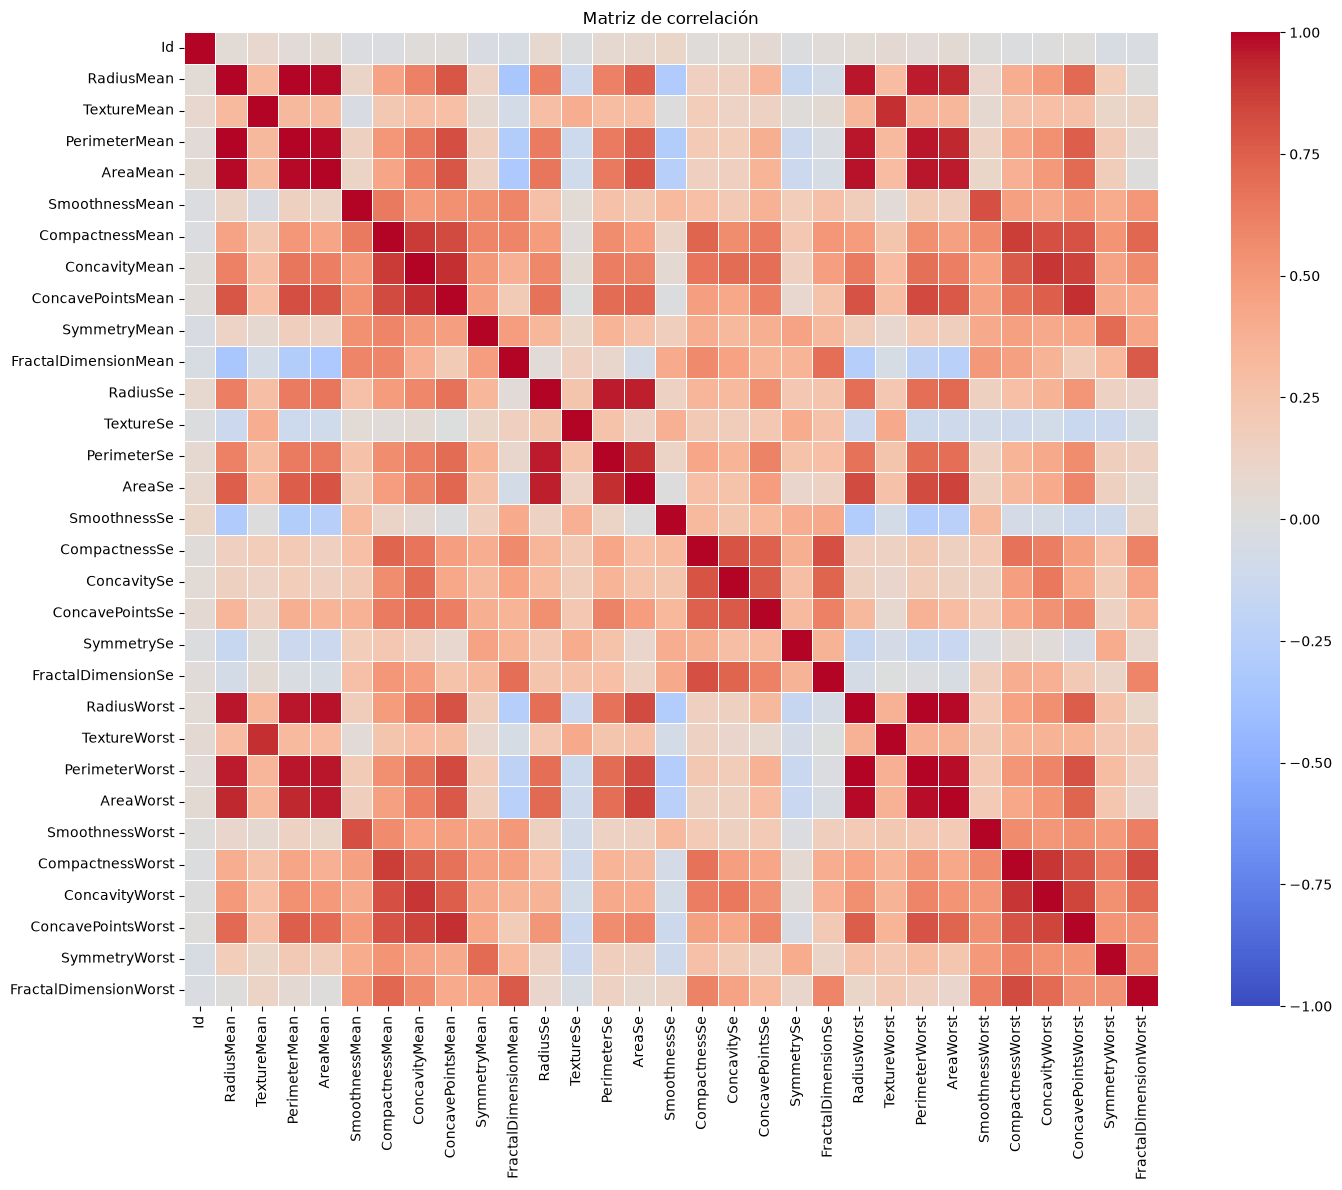

In [69]:
# Gráfico de la matriz de correlación

plt.figure(figsize=(16, 12))

sns.heatmap(
    matriz_correlacion,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

Para complementar el análisis exploratorio de un dataset multivariado como el de Cáncer de Mama y entender mejor las relaciones profundas entre las características, se pueden utilizar varios tipos de gráficos avanzados:

Gráficos de dispersión y pares (sns.pairplot o sns.scatterplot): Permiten cruzar dos variables continuas (por ejemplo, RadiusMean versus PerimeterMean) coloreadas por el diagnóstico, lo que ayuda a identificar agrupamientos (clusters) lineales o no lineales y correlaciones directas entre variables físicas del tumor.

Mapas de calor con agrupamiento jerárquico (sns.clustermap): Van más allá de una matriz de correlación tradicional al reorganizar filas y columnas mediante dendrogramas, agrupando automáticamente características con comportamientos similares y pacientes con perfiles tumorales parecidos.

Gráficos de dispersión con distribución marginal (sns.jointplot): Combinan un diagrama de dispersión central entre dos variables clave con histogramas o curvas de densidad (KDE) en los márgenes superior y derecho, facilitando ver simultáneamente la correlación y la distribución univariada de cada grupo.

Gráficos de coordenadas paralelas (pd.plotting.parallel_coordinates): Útiles para visualizar múltiples dimensiones simultáneamente trazando líneas que conectan los valores normalizados de cada característica por cada paciente, separando visualmente los perfiles malignos de los benignos en un solo plano.

Gráficos de reducción de dimensionalidad (PCA o t-SNE): Permiten proyectar las más de 30 características originales en un espacio bidimensional (componentes principales 1 y 2), visualizando de forma global si las muestras benignas y malignas forman separaciones claras en conjunto.